# 可选实验：逻辑回归的代价函数

## 目标
在本实验中，您将：
- 查看逻辑回归代价函数的实现并使用它。

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from lab_utils_common import  plot_data, sigmoid, dlc
plt.style.use('./deeplearning.mplstyle')

## 数据集
让我们从决策边界实验中使用的同一数据集开始。

In [2]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])                                           #(m,)

我们将使用一个辅助函数绘制这些数据。标签为 $y=1$ 的数据点显示为红色叉号，标签为 $y=0$ 的数据点显示为蓝色圆圈。

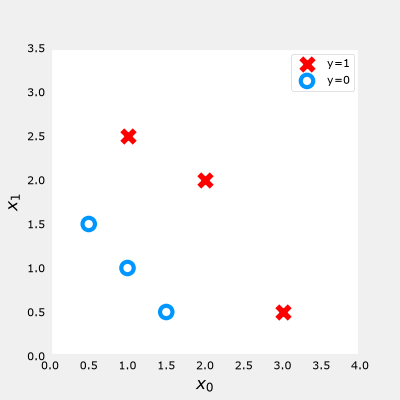

In [4]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
plot_data(X_train, y_train, ax)

# Set both axes to be from 0-4
ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$', fontsize=12)
ax.set_xlabel('$x_0$', fontsize=12)
plt.show()

## 代价函数

在之前的实验中，你开发了*逻辑损失*函数。回想一下，损失是针对单个样本定义的。这里将各个损失组合起来，形成包含所有样本的**代价**。


回想一下，对于逻辑回归，代价函数的形式为

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

其中
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ 是单个数据点的代价，即：

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
* 其中 m 是数据集中的训练样本数量，并且：
$$
\begin{align}
  f_{\mathbf{w},b}(\mathbf{x^{(i)}}) &= g(z^{(i)})\tag{3} \\
  z^{(i)} &= \mathbf{w} \cdot \mathbf{x}^{(i)}+ b\tag{4} \\
  g(z^{(i)}) &= \frac{1}{1+e^{-z^{(i)}}}\tag{5} 
\end{align}
$$

<a name='ex-02'></a>
#### 代码说明

`compute_cost_logistic` 的算法会遍历所有样本，计算每个样本的损失并求和。

请注意，变量 X 和 y 不是标量，而是形状分别为（$m, n$）和（$𝑚$,）的矩阵，其中 $𝑛$ 是特征数量，$𝑚$ 是训练样本数量。

In [5]:
def compute_cost_logistic(X, y, w, b):
    """
    Computes cost

    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """

    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i],w) + b
        f_wb_i = sigmoid(z_i)
        cost +=  -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
             
    cost = cost / m
    return cost


使用下面的单元格检查代价函数的实现。

In [6]:
w_tmp = np.array([1,1])
b_tmp = -3
print(compute_cost_logistic(X_train, y_train, w_tmp, b_tmp))

0.36686678640551745


**预期输出**：0.3668667864055175

## 示例
现在，让我们看看当 $w$ 取另一个值时，代价函数的输出是什么。

* 在之前的实验中，你为 $b = -3, w_0 = 1, w_1 = 1$ 绘制了决策边界。也就是说，当时有 `w = np.array([-3,1,1])`。

* 假设你想看看 $b = -4, w_0 = 1, w_1 = 1$ 或 `w = np.array([-4,1,1])` 是否能得到更好的模型。

首先，为这两个不同的 $b$ 值绘制决策边界，看看哪一个对数据的拟合更好。

* 对于 $b = -3, w_0 = 1, w_1 = 1$，绘制 $-3 + x_0+x_1 = 0$（显示为蓝色）
* 对于 $b = -4, w_0 = 1, w_1 = 1$，绘制 $-4 + x_0+x_1 = 0$（显示为洋红色）

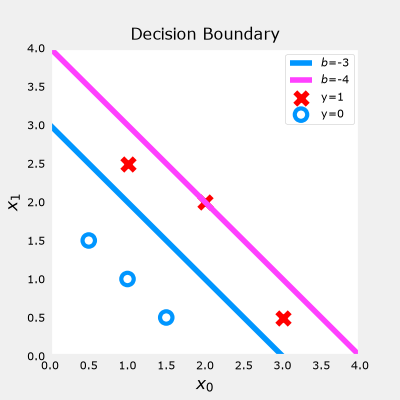

In [7]:
import matplotlib.pyplot as plt

# Choose values between 0 and 6
x0 = np.arange(0,6)

# Plot the two decision boundaries
x1 = 3 - x0
x1_other = 4 - x0

fig,ax = plt.subplots(1, 1, figsize=(4,4))
# Plot the decision boundary
ax.plot(x0,x1, c=dlc["dlblue"], label="$b$=-3")
ax.plot(x0,x1_other, c=dlc["dlmagenta"], label="$b$=-4")
ax.axis([0, 4, 0, 4])

# Plot the original data
plot_data(X_train,y_train,ax)
ax.axis([0, 4, 0, 4])
ax.set_ylabel('$x_1$', fontsize=12)
ax.set_xlabel('$x_0$', fontsize=12)
plt.legend(loc="upper right")
plt.title("Decision Boundary")
plt.show()

从图中可以看到，`w = np.array([-4,1,1])` 对训练数据而言是一个更差的模型。让我们看看代价函数的实现是否反映了这一点。

In [8]:
w_array1 = np.array([1,1])
b_1 = -3
w_array2 = np.array([1,1])
b_2 = -4

print("Cost for b = -3 : ", compute_cost_logistic(X_train, y_train, w_array1, b_1))
print("Cost for b = -4 : ", compute_cost_logistic(X_train, y_train, w_array2, b_2))

Cost for b = -3 :  0.36686678640551745
Cost for b = -4 :  0.5036808636748461


**预期输出**

b = -3 时的代价：0.3668667864055175

b = -4 时的代价：0.5036808636748461


可以看到，代价函数的表现符合预期，而且 `w = np.array([-4,1,1])` 的代价确实高于 `w = np.array([-3,1,1])` 的代价

## 恭喜！
在本实验中，你研究并使用了逻辑回归的代价函数。